In [28]:
# Import de librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de estilos para los gráficos
# Estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})
                                                                                                                        
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
                                                                                                                        
DATA_DIR = Path('data')

# Paleta diagnóstica consistente en todo el EDA                                                                             
DX_PALETTE = {'CN': '#2ecc71', 'MCI': '#f39c12', 'AD': '#e74c3c'}
DX_ORDER   = ['CN', 'MCI', 'AD']

In [47]:
df_raw = pd.read_csv(DATA_DIR / 'TADPOLE_D1_D2.csv', low_memory=False)

print(f'Shape raw: {df_raw.shape}')
print(f'Número de features: {df_raw.shape[1]}')
print(f'Número de pacientes únicos: {df_raw["RID"].nunique()}')
print('\nTipos de columnas:\n', df_raw.dtypes.value_counts())

Shape raw: (12741, 1907)
Número de features: 1907
Número de pacientes únicos: 1737

Tipos de columnas:
 str        1827
float64      72
int64         8
Name: count, dtype: int64


#  1.- CALIDAD DE DATOS

Antes de seguir con el EDA, es importante seleccionar los datos con los que vamos a trabajar. Es importante entender de donde viene cada registro para saber si nos resta útil o no.

El diccionario nos indica que hay dos campos, **D1** y **D2**, que indican de que base de datos procede el registro. Estos valores indican el split, y son los siguientes:
| D1  | D2  | Significado                                                                                                   |
|-----|-----|---------------------------------------------------------------------------------------------------------------|
| 1   | 0   | Solo en entrenamiento — visitas históricas de pacientes que no llegaron al periodo de predicción              |
| 1   | 1   | En ambos — pacientes que tienen historial (D1) y también visitas en la ventana de predicción (D2)             |
| 0   | 1   | Solo en predicción — visitas sin historial previo en D1                                                       |
| 0   | 0   | Ninguno — filas marginales/administrativas, no se usan                                                        |


Una vez visto esto, haremos el EDA sobre todos los registros, pero eliminándo aquellos que tienen D1 = D2 = 0. El resto lo trataremos igual.

In [48]:
# Eliminamos las filas donde D1 = 0 y D2 = 0
df_raw = df_raw[(df_raw['D1'] != 0) | (df_raw['D2'] != 0)]

print(f'Shape después de eliminar filas: {df_raw.shape}')
print(f'Número de pacientes únicos después de eliminar filas: {df_raw["RID"].nunique()}')

Shape después de eliminar filas: (12685, 1907)
Número de pacientes únicos después de eliminar filas: 1681


###  1.1.- VALORES NULOS

In [49]:
                                                                                                       
missing = pd.DataFrame({
    'missing_count': df_raw.isnull().sum(),
    'missing_pct':   df_raw.isnull().sum() / len(df_raw) * 100
}).sort_values('missing_pct', ascending=False)

print(f'Columnas sin ningún nulo: {(missing["missing_pct"] == 0).sum()}')
print(f'Columnas con >50% nulos: {(missing["missing_pct"] > 50).sum()}')
print(f'Columnas con >90% nulos: {(missing["missing_pct"] > 90).sum()}')
print(f'Columnas con 100% nulos: {(missing["missing_pct"] == 100).sum()}')

print('\nTop 20 columnas con más nulos:')                                                                                     
print(missing.head(20).to_string())      

Columnas sin ningún nulo: 1452
Columnas con >50% nulos: 35
Columnas con >90% nulos: 2
Columnas con 100% nulos: 0

Top 20 columnas con más nulos:
                missing_count  missing_pct
PIB_bl                  12540       98.857
PIB                     12463       98.250
AV45                    10581       83.413
FDG                      9360       73.788
EcogSPOrgan              7845       61.845
EcogPtOrgan              7795       61.451
EcogSPDivatt             7751       61.104
MOCA                     7739       61.009
EcogPtVisspat            7723       60.883
EcogPtDivatt             7721       60.867
EcogSPVisspat            7712       60.796
EcogPtPlan               7693       60.646
EcogPtLang               7683       60.568
EcogPtTotal              7679       60.536
EcogSPPlan               7676       60.512
EcogPtMem                7668       60.449
EcogSPMem                7623       60.095
EcogSPTotal              7621       60.079
EcogSPLang               7617       60

### 1.2.- DUPLICADOS

In [50]:
n_dup_filas = df_raw.duplicated().sum()
n_dup_paciente_visita = df_raw.duplicated(subset=['RID', 'EXAMDATE']).sum()

print(f'Filas duplicadas exactas: {n_dup_filas}')
print(f'Duplicados por (RID + EXAMDATE): {n_dup_paciente_visita}')

if n_dup_paciente_visita > 0:
    print('\nEjemplos de duplicados por paciente+fecha:')
    mask = df_raw.duplicated(subset=['RID', 'EXAMDATE'], keep=False)
    print(df_raw[mask][['RID', 'EXAMDATE', 'VISCODE', 'DX']].head(10))

Filas duplicadas exactas: 0
Duplicados por (RID + EXAMDATE): 3

Ejemplos de duplicados por paciente+fecha:
        RID    EXAMDATE VISCODE   DX
5576   1195  2011-02-15     m48   NL
8376   1088  2013-01-23     m78  NaN
8586   1195  2011-02-15     m42  NaN
11633  1088  2013-01-23     m72  NaN
12214  4960  2015-11-16     m36   NL
12215  4960  2015-11-16     m48   NL


### 1.3.- CONSISTENCIA TEMPORAL

In [51]:
df_raw['EXAMDATE'] = pd.to_datetime(df_raw['EXAMDATE'])
df_sorted = df_raw.sort_values(['RID', 'EXAMDATE'])

# Intervalo entre visitas consecutivas del mismo paciente
df_sorted['days_diff'] = df_sorted.groupby('RID')['EXAMDATE'].diff().dt.days

# Pacientes con fechas invertidas (diff negativa)
n_fechas_invertidas = (df_sorted['days_diff'] < 0).sum()

# Visitas con intervalo 0 (misma fecha, distinta fila)
n_mismo_dia = (df_sorted['days_diff'] == 0).sum()

print(f'Visitas con fecha invertida (diff < 0): {n_fechas_invertidas}')
print(f'Visitas con mismo día que la anterior: {n_mismo_dia}')
print('\nRango temporal del dataset:')
print(f'  Desde: {df_raw["EXAMDATE"].min().date()}')
print(f'  Hasta: {df_raw["EXAMDATE"].max().date()}')
print('\nIntervalo entre visitas (días):')
print(df_sorted['days_diff'].dropna().describe().round(1))

Visitas con fecha invertida (diff < 0): 0
Visitas con mismo día que la anterior: 3

Rango temporal del dataset:
  Desde: 2005-09-07
  Hasta: 2017-05-05

Intervalo entre visitas (días):
count   11004.000
mean      207.300
std       120.500
min         0.000
25%       168.000
50%       183.000
75%       202.000
max      1763.000
Name: days_diff, dtype: float64


### 1.4.- VALORES ÚNICOS EN CATEGORÍAS CLAVE

In [52]:
cat_cols = ['DX', 'DX_bl', 'PTGENDER', 'PTETHCAT', 'PTRACCAT', 'PTMARRY', 'APOE4']

for col in cat_cols:
    if col in df_raw.columns:
        print(f'\n{col}:')
        print(df_raw[col].value_counts(dropna=False).to_string())


DX:
DX
MCI                3909
NaN                3831
NL                 2658
Dementia           1715
MCI to Dementia     372
NL to MCI           108
MCI to NL            77
Dementia to MCI      12
NL to Dementia        3

DX_bl:
DX_bl
LMCI    4627
CN      3813
EMCI    2310
AD      1549
SMC      386

PTGENDER:
PTGENDER
Male      7187
Female    5498

PTETHCAT:
PTETHCAT
Not Hisp/Latino    12287
Hisp/Latino          340
Unknown               58

PTRACCAT:
PTRACCAT
White                11814
Black                  489
Asian                  224
More than one          112
Am Indian/Alaskan       20
Unknown                 18
Hawaiian/Other PI        8

PTMARRY:
PTMARRY
Married          9739
Widowed          1512
Divorced         1006
Never married     378
Unknown            50

APOE4:
APOE4
0.000    7015
1.000    4516
2.000    1153
NaN         1


# 2.- LIMPIEZA

In [53]:
# Eliminar columnas con >98% nulos (PIB, PIB_bl) y FLDSTRENG
cols_drop = ['PIB', 'PIB_bl', 'FLDSTRENG']
df_raw = df_raw.drop(columns=[c for c in cols_drop if c in df_raw.columns])

# Resolver duplicados (RID + EXAMDATE): quedarse con el VISCODE más alto
df_raw['viscode_num'] = df_raw['VISCODE'].str.extract(r'(\d+)').astype(float)
df_raw = (df_raw
        .sort_values(['RID', 'EXAMDATE', 'viscode_num'], ascending=[True, True, False])
        .drop_duplicates(subset=['RID', 'EXAMDATE'], keep='first')
        .drop(columns='viscode_num')
        .reset_index(drop=True))
                
print(f'Shape tras limpieza: {df_raw.shape}')
print(f'Pacientes únicos:    {df_raw["RID"].nunique()}')
print(f'Duplicados restantes (RID+EXAMDATE): {df_raw.duplicated(subset=["RID","EXAMDATE"]).sum()}')

Shape tras limpieza: (12682, 1904)
Pacientes únicos:    1681
Duplicados restantes (RID+EXAMDATE): 0


# 3.- SELECCIÓN DE VARIABLES

In [ ]:
COLS_ID     = ['RID', 'PTID', 'EXAMDATE', 'VISCODE', 'D1', 'D2']
COLS_TARGET = ['DX', 'DX_bl']
COLS_DEMO   = ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'PTMARRY', 'APOE4']
COLS_COG    = ['CDRSB', 'ADAS11', 'ADAS13', 'MMSE',
                'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'RAVLT_perc_forgetting',
                'FAQ', 'MOCA']
COLS_MRI    = ['Hippocampus', 'Ventricles', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']
COLS_CSF    = ['ABETA_UPENNBIOMK9_04_19_17', 'TAU_UPENNBIOMK9_04_19_17', 'PTAU_UPENNBIOMK9_04_19_17']
COLS_PET    = ['FDG', 'AV45']

all_cols = COLS_ID + COLS_TARGET + COLS_DEMO + COLS_COG + COLS_MRI + COLS_CSF + COLS_PET
all_cols = [c for c in all_cols if c in df_raw.columns]

df = df_raw[all_cols].copy()
df = df.sort_values(['RID', 'EXAMDATE']).reset_index(drop=True)

print(f'Variables seleccionadas: {df.shape[1]}')
print(f'Filas: {df.shape[0]}')
print(f'Pacientes únicos: {df["RID"].nunique()}')

print('\nVariables por categoría:')
print(f'  Identificadores: {len([c for c in COLS_ID if c in df.columns])}')
print(f'  Target: {len([c for c in COLS_TARGET if c in df.columns])}')
print(f'  Demográficas: {len([c for c in COLS_DEMO if c in df.columns])}')
print(f'  Cognitivas: {len([c for c in COLS_COG if c in df.columns])}')
print(f'  MRI: {len([c for c in COLS_MRI if c in df.columns])}')
print(f'  CSF: {len([c for c in COLS_CSF if c in df.columns])}')
print(f'  PET: {len([c for c in COLS_PET if c in df.columns])}')

Variables seleccionadas: 37
Filas:                   12682
Pacientes únicos:        1681

Variables por categoría:
  Identificadores: 6
  Target:          2
  Demográficas:    7
  Cognitivas:      10
  MRI:             7
  CSF:             3
  PET:             2


# 4.- 

### 4.1.- ESTADÍSTICOS DESCRIPTIVOS

In [61]:
csf_cols = ['ABETA_UPENNBIOMK9_04_19_17', 'TAU_UPENNBIOMK9_04_19_17', 'PTAU_UPENNBIOMK9_04_19_17']
for col in csf_cols:
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

num_cols = COLS_COG + COLS_MRI + COLS_PET + COLS_CSF
num_cols = [c for c in num_cols if c in df.columns]

stats = df[num_cols].describe().T
stats['missing_pct'] = df[num_cols].isnull().mean().round(3) * 100
stats = stats[['count', 'missing_pct', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

print('=== Variables cognitivas ===')
print(stats.loc[[c for c in COLS_COG if c in df.columns]].round(2).to_string())
print('\n=== Variables MRI ===')
print(stats.loc[[c for c in COLS_MRI if c in df.columns]].round(2).to_string())
print('\n=== PET + CSF ===')
print(stats.loc[[c for c in COLS_PET + COLS_CSF if c in df.columns]].round(2).to_string())

=== Variables cognitivas ===
                         count  missing_pct   mean    std      min    25%    50%     75%     max
CDRSB                 8905.000       29.800  2.170  2.810    0.000  0.000  1.000   3.000  18.000
ADAS11                8856.000       30.200 11.390  8.640    0.000  5.330  9.000  15.000  70.000
ADAS13                8770.000       30.800 17.500 11.710    0.000  9.000 15.000  24.000  85.000
MMSE                  8875.000       30.000 26.590  3.950    0.000 25.000 28.000  29.000  30.000
RAVLT_immediate       8775.000       30.800 34.490 13.610    0.000 25.000 33.000  44.000  75.000
RAVLT_learning        8775.000       30.800  4.030  2.820   -5.000  2.000  4.000   6.000  14.000
RAVLT_forgetting      8749.000       31.000  4.230  2.530  -12.000  3.000  4.000   6.000  15.000
RAVLT_perc_forgetting 8680.000       31.600 59.710 38.380 -500.000 30.000 62.500 100.000 100.000
FAQ                   8939.000       29.500  5.590  7.920    0.000  0.000  1.000   9.000  30.000
M

### 4.2.- DIAGNÓSTICO DE VALORES ANÓMALOS

In [ ]:
print('RAVLT_perc_forgetting < -10:')
print(df[df['RAVLT_perc_forgetting'] < -10][['RID', 'EXAMDATE', 'RAVLT_perc_forgetting']].shape[0], 'filas')
                                                                                                                           
print('\nMMSE == 0:')
print(df[df['MMSE'] == 0][['RID', 'EXAMDATE', 'MMSE']].shape[0], 'filas')

print('\nICV < 1000:')
print(df[df['ICV'] < 1000][['RID', 'EXAMDATE', 'ICV']].head(10))

RAVLT_perc_forgetting < -10:
89 filas

MMSE == 0:
5 filas

ICV < 1000:
        RID   EXAMDATE     ICV
10855  4630 2012-08-21 291.884


### 4.3.- CORRECCIÓN DE VALORES ANÓMALOS

In [63]:
df.loc[df['RAVLT_perc_forgetting'] < -10, 'RAVLT_perc_forgetting'] = np.nan
df.loc[df['ICV'] < 1000, 'ICV'] = np.nan

print('Correcciones aplicadas:')
print('  RAVLT_perc_forgetting < -10 → NaN')
print('  ICV < 1000 → NaN (1 fila: RID 4630)')
print(f'\nShape tras correcciones: {df.shape}')
                                                

Correcciones aplicadas:
  RAVLT_perc_forgetting < -10 → NaN
  ICV < 1000 → NaN (1 fila: RID 4630)

Shape tras correcciones: (12682, 37)


### 4.4.- DISTRIBUCIONES VARIABLES COGNITIVAS

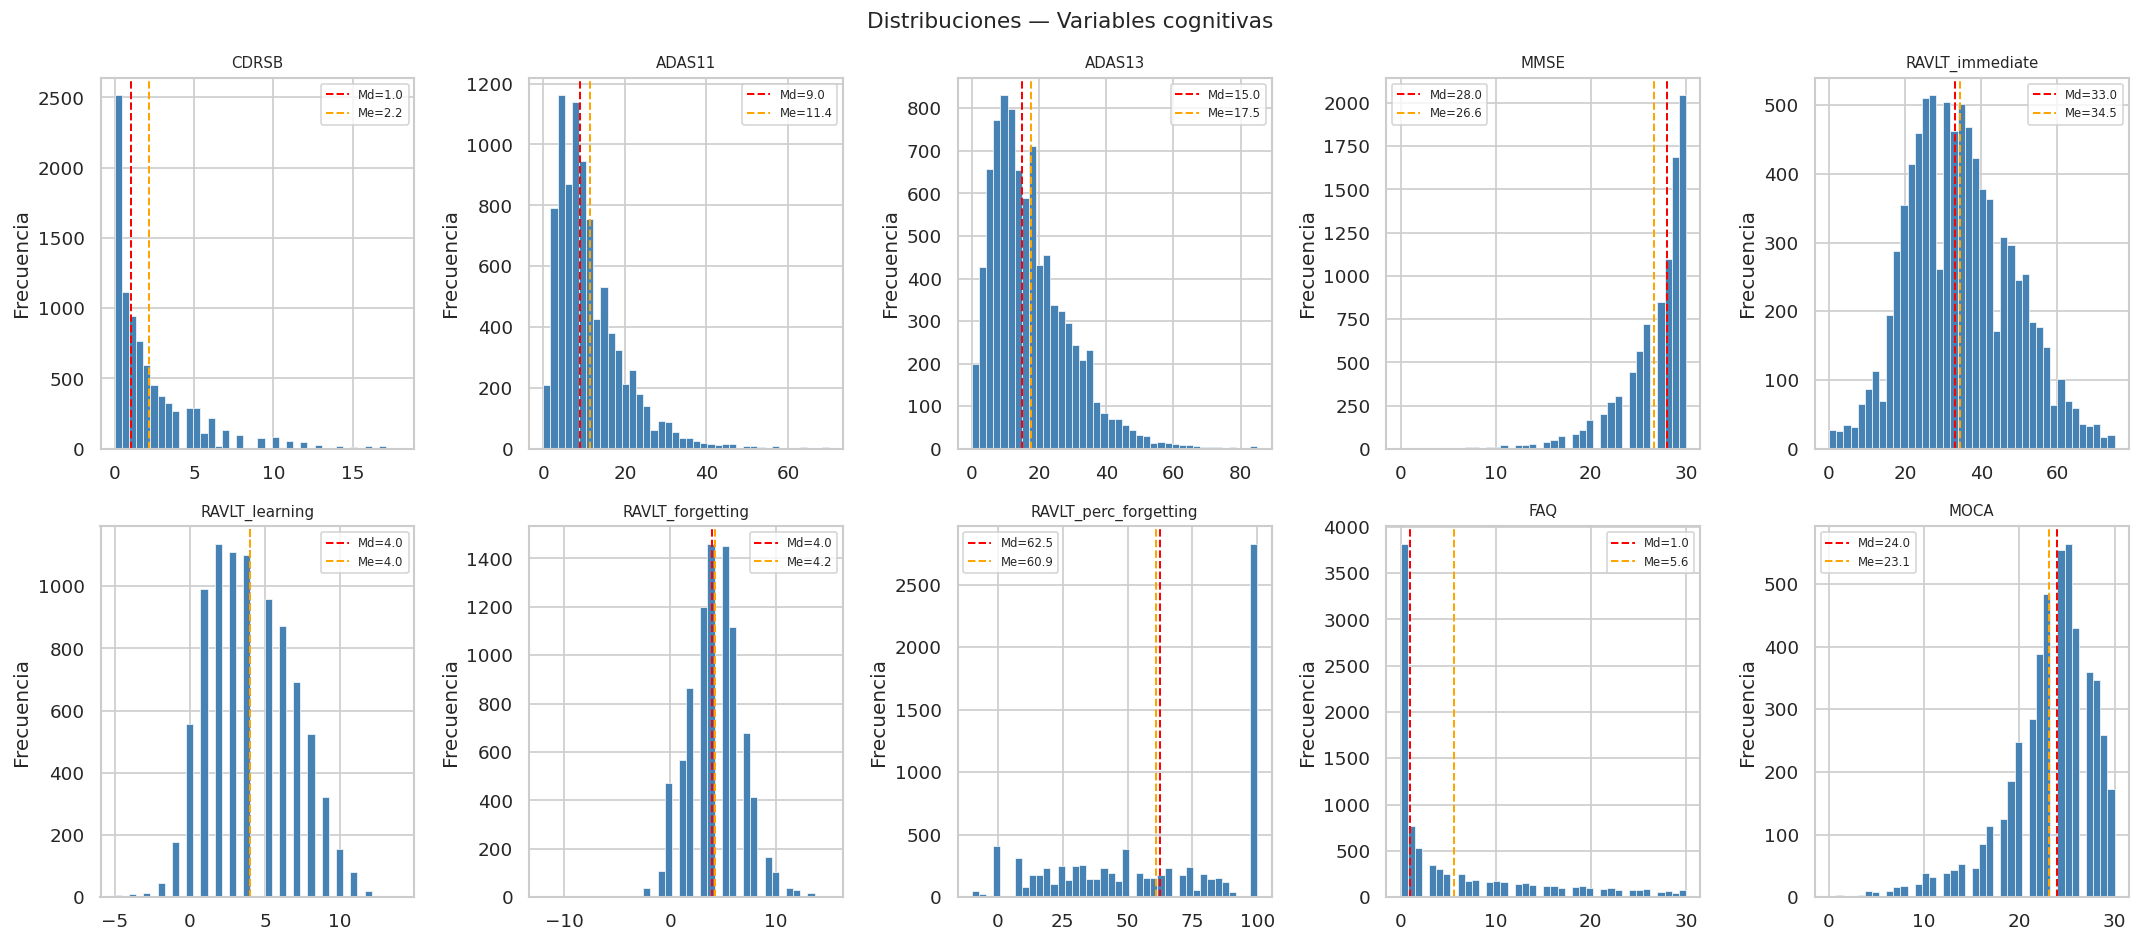

In [64]:
cog_cols = [c for c in COLS_COG if c in df.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cog_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'Md={data.median():.1f}')
    axes[i].axvline(data.mean(), color='orange', linestyle='--', linewidth=1.2, label=f'Me={data.mean():.1f}')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Frecuencia')

for j in range(len(cog_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuciones — Variables cognitivas', fontsize=13)
plt.tight_layout()
plt.show()

### 4.5.- DISTRIBUCIONES VARIABLES MRI

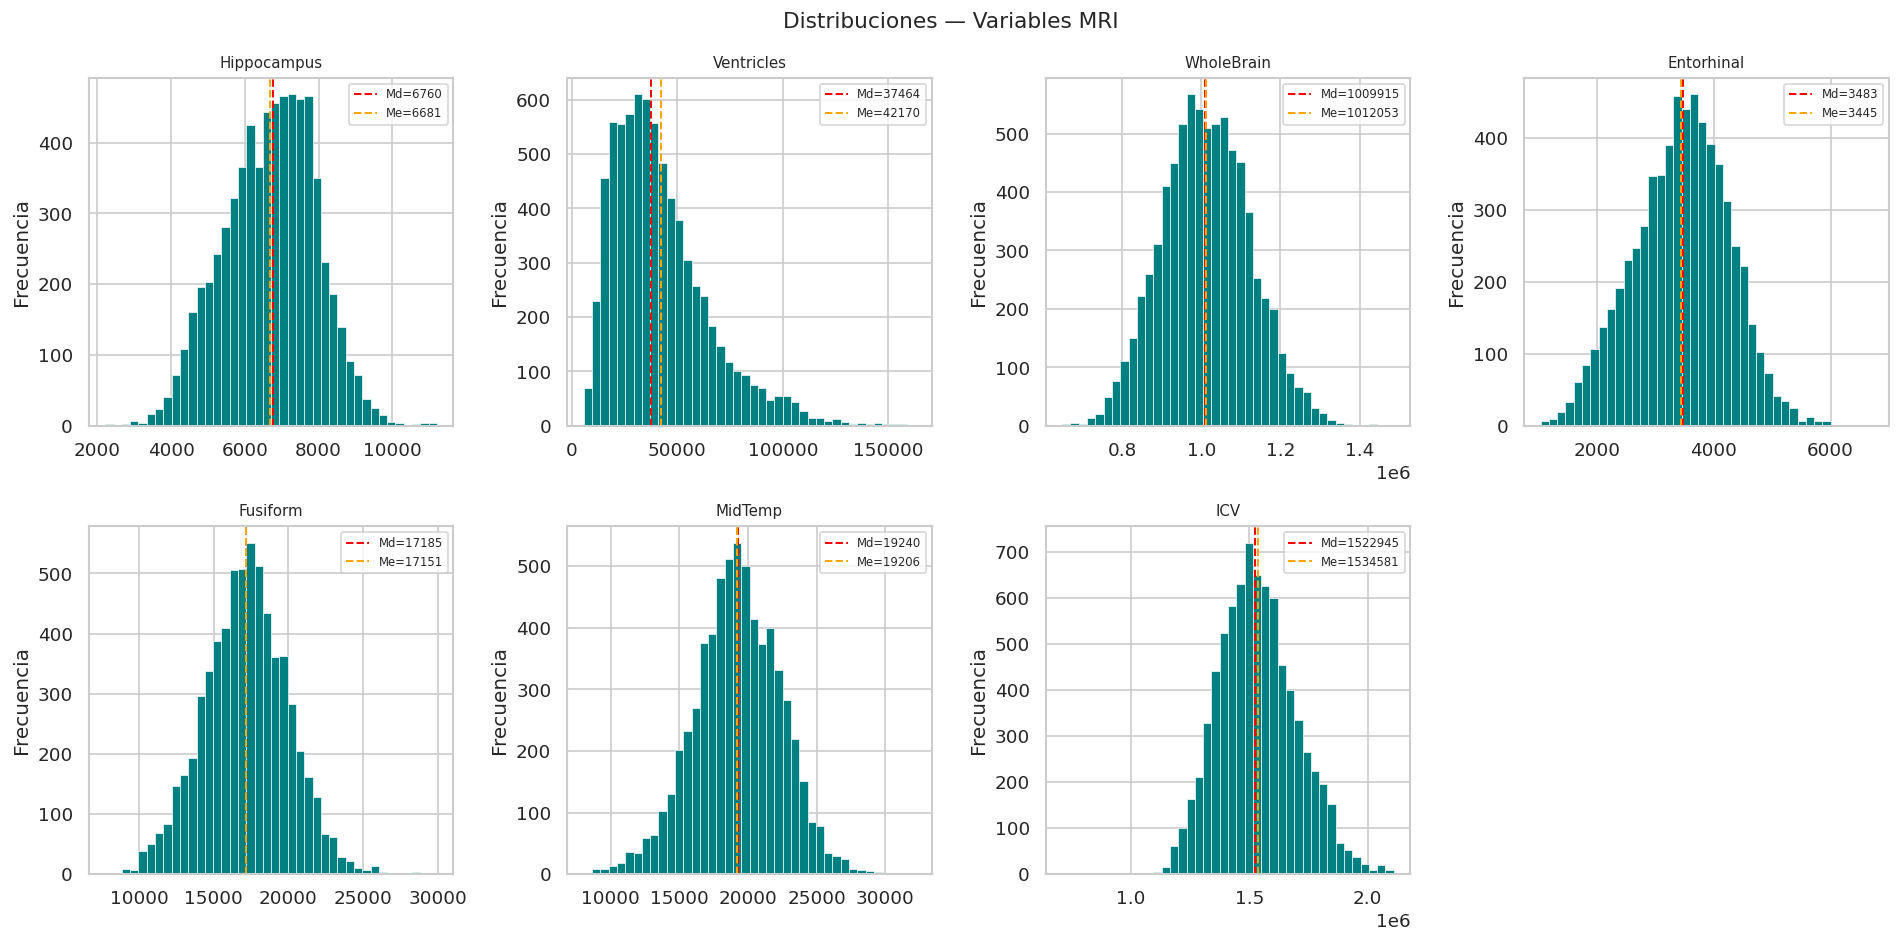

In [65]:
mri_cols = [c for c in COLS_MRI if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(mri_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='teal', edgecolor='white', linewidth=0.4)
    axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'Md={data.median():.0f}')
    axes[i].axvline(data.mean(), color='orange', linestyle='--', linewidth=1.2, label=f'Me={data.mean():.0f}')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Frecuencia')

for j in range(len(mri_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuciones — Variables MRI', fontsize=13)
plt.tight_layout()
plt.show()

Durante el análisis exploratorio de los datos se han identificado distintos comportamientos en las distribuciones de las variables, lo cual tiene implicaciones directas en el preprocesamiento y modelado.

En primer lugar, las variables cognitivas como **CDRSB** y **FAQ** presentan una distribución fuertemente sesgada a la derecha, evidenciando un claro *floor effect*. Esto indica que la mayoría de los pacientes no presentan deterioro significativo, concentrando los valores en rangos bajos. Por otro lado, **ADAS11** y **ADAS13** también muestran asimetría positiva, algo esperable en este tipo de datasets clínicos. En ambos casos, se considera adecuado aplicar una transformación logarítmica (`log1p`) para estabilizar la varianza y mejorar el comportamiento del modelo.

En contraste, **MMSE** presenta una distribución sesgada a la izquierda, con acumulación en valores cercanos a 30, lo que refleja un *ceiling effect* típico en poblaciones mayoritariamente sanas o con deterioro leve (CN/MCI). Este comportamiento se considera coherente y no requiere transformación específica.

La variable **RAVLT_perc_forgetting** muestra un pico pronunciado en el 100%, correspondiente a pacientes que olvidan completamente la información. Aunque esta concentración es notable, se interpreta como un patrón válido del dominio y no se recomienda modificarla. Sin embargo, **MOCA** presenta un comportamiento atípico con un pico en valores muy bajos (0-5), lo que sugiere la posible presencia de artefactos o problemas en la recogida de datos, siendo necesaria una revisión más detallada.

Por otro lado, variables como **RAVLT_learning** y **RAVLT_forgetting** presentan distribuciones aproximadamente normales, lo que indica una adecuada calidad estadística para su uso directo en el modelo.

En cuanto a las variables derivadas de MRI, **Ventricles** muestra una distribución sesgada a la derecha, por lo que se propone aplicar una transformación logarítmica. En cambio, estructuras como **Hippocampus**, **Entorhinal**, **Fusiform** y **MidTemp** presentan distribuciones aproximadamente normales, siendo suficiente una normalización estándar. Finalmente, variables globales como **WholeBrain** e **ICV** muestran distribuciones simétricas y bien comportadas, sin requerir transformaciones adicionales.

En base a este análisis, se establece como estrategia de preprocesamiento la aplicación de transformaciones `log1p` en aquellas variables con fuerte asimetría (**CDRSB, FAQ, ADAS11, ADAS13, Ventricles**), mientras que el resto de variables serán escaladas mediante normalización estándar (`StandardScaler`).